# Time-Dependent Readout Resonator Photon: Qubit Spectroscopy vs Delay Time
Load `ds_raw.h5` from a time-dependent RR photon qubit-spectroscopy sweep over `delay_time`,
run `QubitSpectroscopyAnalyzer` on each slice, and plot the peak frequency vs delay time.

In [2]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scqat.parsers.xarray_h5_parser import load_xarray_h5
from scqat.parsers.qualibrate_parser import repetition_data
from scqat.protocols.qubit_spectroscopy import QubitSpectroscopyAnalyzer

## 1. Configuration

In [31]:
DATA_FOLDER = r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\weak_RO_pulse_AC\#431_LCH_time_dep_rr_photon_134812_100"

DS_RAW_PATH = os.path.join(DATA_FOLDER, "ds_raw.h5")
FIGURE_SAVE_PATH = os.path.join(DATA_FOLDER, "figures")
os.makedirs(FIGURE_SAVE_PATH, exist_ok=True)

file_output = "temmp.h5"

chi_eff = -0.075 * 2

## 2. Load Dataset

In [32]:
dataset = load_xarray_h5(DS_RAW_PATH)
# Split by qubit and pick the first one
sq_data = repetition_data(dataset)[0]
# Combine I and Q into complex IQdata
sq_data["IQdata"] = sq_data["I"] + 1j * sq_data["Q"]
print(sq_data)


<xarray.Dataset> Size: 981kB
Dimensions:     (delay_time: 401, detuning: 61)
Coordinates:
  * delay_time  (delay_time) int32 2kB 0 20 40 60 80 ... 7940 7960 7980 8000
  * detuning    (detuning) float64 488B -1e+08 -9.8e+07 ... 1.8e+07 2e+07
    qubit       <U2 8B 'q1'
Data variables:
    I1          (detuning, delay_time) int32 98kB 0 0 0 0 0 0 0 ... 0 0 0 0 0 0
    Q1          (detuning, delay_time) int32 98kB 0 0 0 0 0 0 0 ... 0 0 0 0 0 0
    I           (detuning, delay_time) float64 196kB -0.002401 ... -0.001527
    Q           (detuning, delay_time) float64 196kB -0.001096 ... -0.001228
    IQdata      (detuning, delay_time) complex128 391kB (-0.00240146283060312...


## 3. 2D Overview Plot (raw signal vs detuning and delay_time)

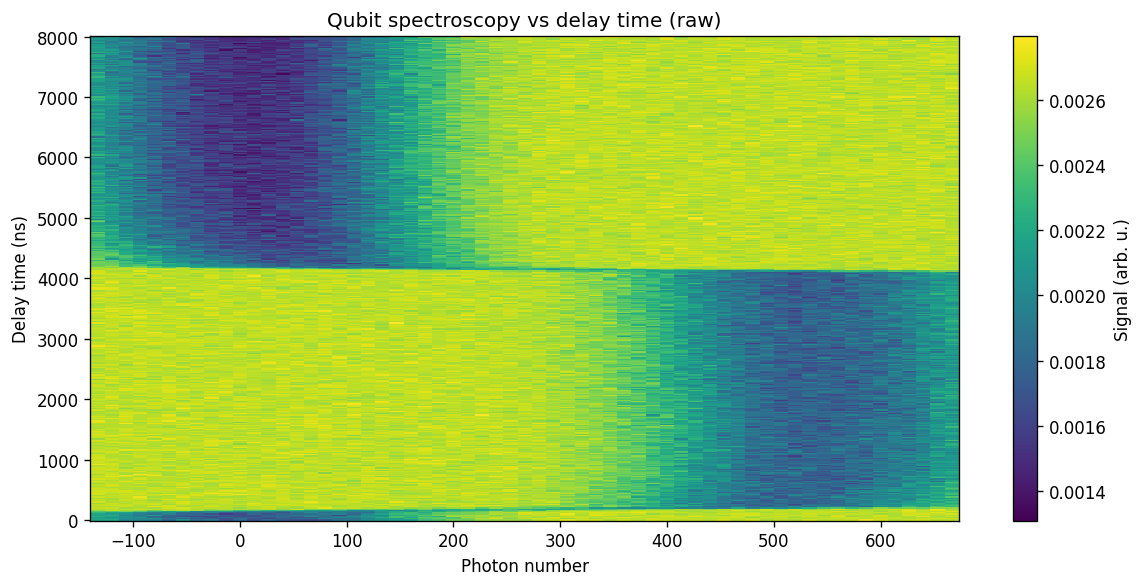

In [33]:
detuning = sq_data.coords["detuning"].values
delay_time = sq_data.coords["delay_time"].values

delay_time_label = "Delay time (ns)"

# Detuning axis: convert to photon number if chi_eff is provided
if chi_eff is not None:
    det_axis = detuning / 1e6 / chi_eff
    det_axis_label = "Photon number"
else:
    det_axis = detuning / 1e6
    det_axis_label = "Detuning (MHz)"

# Build 2D signal from complex IQdata
signal_2d = np.abs(sq_data["IQdata"].values)

fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
im = ax.pcolormesh(
    det_axis, delay_time, signal_2d.T,
    shading="auto", cmap="viridis",
)
ax.set_xlabel(det_axis_label)
ax.set_ylabel(delay_time_label)
ax.set_title("Qubit spectroscopy vs delay time (raw)")
fig.colorbar(im, ax=ax, label="Signal (arb. u.)")
fig.tight_layout()
fig.savefig(os.path.join(FIGURE_SAVE_PATH, "time_dep_rr_photon_2d_raw.png"), bbox_inches="tight")
plt.show()


## 4. Run QubitSpectroscopyAnalyzer per delay_time

In [34]:
analyzer = QubitSpectroscopyAnalyzer()

peak_detunings = []
peak_freqs = []
peak_delay_times = []
ref_iqs = []
signals = []

for i, dt in enumerate(sq_data.coords["delay_time"].values):
    # Select single delay_time slice
    slice_ds = sq_data.sel(delay_time=dt)

    results, _ = analyzer.analyze(slice_ds, skip_figures=True, max_peaks=1)

    ref_iqs.append(results["ref_iq"])
    signals.append(results["signal"])

    if len(results["peaks"]) == 1:
        pk = results["peaks"][0]
        peak_detunings.append(pk["detuning"])
        peak_freqs.append(pk.get("full_freq", np.nan))
        peak_delay_times.append(float(dt))
    else:
        peak_detunings.append(np.nan)
        peak_freqs.append(np.nan)
        peak_delay_times.append(float(dt))

peak_detunings = np.array(peak_detunings)
peak_freqs = np.array(peak_freqs)
peak_delay_times = np.array(peak_delay_times)
ref_iqs = np.array(ref_iqs)
signals = np.array(signals)

print(f"Peaks found in {np.isfinite(peak_detunings).sum()} / {len(delay_time)} slices")

Peaks found in 401 / 401 slices


## 5. 2D Plot with Peak Overlay

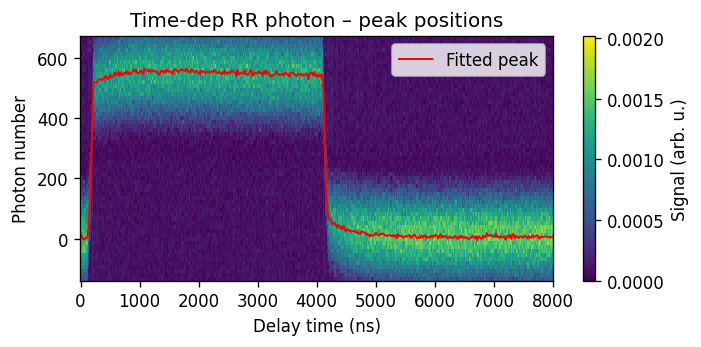

In [35]:
fig, ax = plt.subplots(figsize=(6, 3), dpi=120)
im = ax.pcolormesh(
    delay_time, det_axis, signals.T,
    shading="auto", cmap="viridis",
)
# Overlay extracted peaks
mask = np.isfinite(peak_detunings)
peak_det_axis = peak_detunings[mask] / 1e6 / chi_eff if chi_eff is not None else peak_detunings[mask] / 1e6
ax.plot(
    peak_delay_times[mask], peak_det_axis,
    "r-", ms=6, lw=1.2, label="Fitted peak",
)
ax.set_xlabel(delay_time_label)
ax.set_ylabel(det_axis_label)
ax.set_title("Time-dep RR photon \u2013 peak positions")
ax.legend()
fig.colorbar(im, ax=ax, label="Signal (arb. u.)")
fig.tight_layout()
fig.savefig(os.path.join(FIGURE_SAVE_PATH, "time_dep_rr_photon_2d_peaks.png"), bbox_inches="tight")
plt.show()

## 5b. Single Delay-Time Line Cut – Data & Fit

Requested: 0 ns → nearest: 0 ns (index 0)


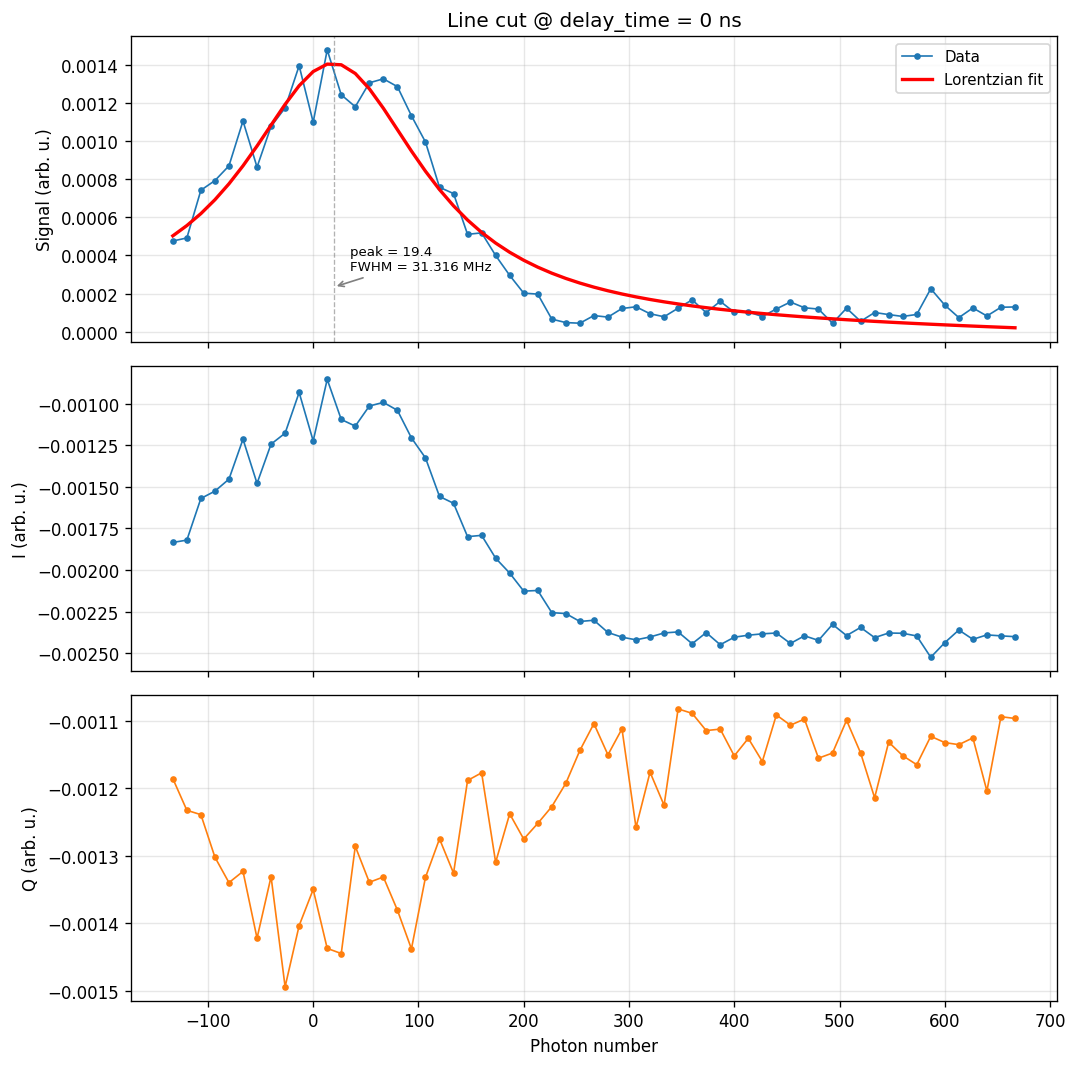

In [36]:
# --- Choose a delay time to inspect ---
check_delay_time = 0  # ns  <-- change this manually

# Find the nearest delay_time in the dataset
dt_vals = sq_data.coords["delay_time"].values
idx_nearest = int(np.argmin(np.abs(dt_vals - check_delay_time)))
dt_nearest = dt_vals[idx_nearest]
print(f"Requested: {check_delay_time} ns → nearest: {dt_nearest} ns (index {idx_nearest})")

# Run the analyzer on this single slice
slice_ds = sq_data.sel(delay_time=dt_nearest)
results_check, _ = analyzer.analyze(slice_ds, skip_figures=True, max_peaks=1)

det = slice_ds.coords["detuning"].values
signal_check = results_check["signal"]
iq_slice = slice_ds["IQdata"].values.ravel()

# X-axis: photon number or detuning
if chi_eff is not None:
    x_data = det / 1e6 / chi_eff
    x_label = "Photon number"
else:
    x_data = det / 1e6
    x_label = "Detuning (MHz)"

fig, axes = plt.subplots(3, 1, figsize=(9, 9), dpi=120, sharex=True)

# --- Top: |IQ - ref| signal with fit ---
ax = axes[0]
ax.plot(x_data, signal_check, "o-", ms=3, lw=1, label="Data")

for pk in results_check["peaks"]:
    fit_x = pk["fit_x"]
    fit_y_raw = pk["fit_y"]
    baseline_at_fit = np.interp(fit_x, det, results_check["baseline"])
    if results_check["inverted"]:
        fit_y_overlay = baseline_at_fit - fit_y_raw
    else:
        fit_y_overlay = baseline_at_fit + fit_y_raw

    fit_x_plot = fit_x / 1e6 / chi_eff if chi_eff is not None else fit_x / 1e6
    ax.plot(fit_x_plot, fit_y_overlay, "r-", lw=2, label="Lorentzian fit")

    pk_det = pk["detuning"]
    pk_photon = pk_det / 1e6 / chi_eff if chi_eff is not None else pk_det / 1e6
    ax.axvline(pk_photon, color="gray", ls="--", lw=0.8, alpha=0.6)
    ax.annotate(
        f"peak = {pk_photon:.1f}\nFWHM = {pk['fwhm']/1e6:.3f} MHz",
        xy=(pk_photon, fit_y_overlay[len(fit_y_overlay)//2]),
        xytext=(10, 10), textcoords="offset points", fontsize=8,
        arrowprops=dict(arrowstyle="->", color="gray"),
    )

ax.set_ylabel("Signal (arb. u.)")
ax.set_title(f"Line cut @ delay_time = {dt_nearest} ns")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Middle: I vs x_data ---
ax = axes[1]
ax.plot(x_data, iq_slice.real, "o-", ms=3, lw=1, color="C0")
ax.set_ylabel("I (arb. u.)")
ax.grid(True, alpha=0.3)

# --- Bottom: Q vs x_data ---
ax = axes[2]
ax.plot(x_data, iq_slice.imag, "o-", ms=3, lw=1, color="C1")
ax.set_xlabel(x_label)
ax.set_ylabel("Q (arb. u.)")
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 6. Peak Detuning vs Delay Time

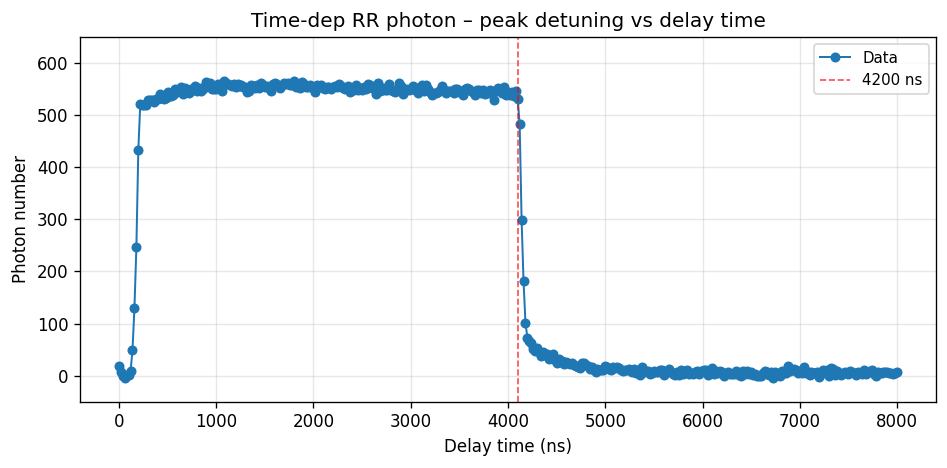

In [37]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=120)
mask = np.isfinite(peak_detunings)

x_plot = peak_delay_times[mask]
y_plot = peak_detunings[mask] / 1e6 / chi_eff if chi_eff is not None else peak_detunings[mask] / 1e6

ax.plot(x_plot, y_plot, "o-", ms=5, lw=1.2, label="Data")
ax.axvline(4100, color="r", ls="--", lw=1, alpha=0.7, label="4200 ns")
ax.set_xlabel(delay_time_label)
ax.set_ylim((-50, 650))
ax.set_ylabel(det_axis_label)
ax.set_title("Time-dep RR photon \u2013 peak detuning vs delay time")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(FIGURE_SAVE_PATH, "time_dep_rr_photon_peak_vs_delay.png"), bbox_inches="tight")
plt.show()

## 7. Peak Summary

In [38]:
print(f"{'Delay time (ns)':>16s}  {'Peak detuning (MHz)':>20s}  {'Peak freq (GHz)':>16s}")
print("-" * 58)
for dt, det, freq in zip(peak_delay_times, peak_detunings, peak_freqs):
    det_str = f"{det / 1e6:.3f}" if np.isfinite(det) else "no peak"
    freq_str = f"{freq / 1e9:.6f}" if np.isfinite(freq) else "\u2014"
    print(f"{dt:16.1f}  {det_str:>20s}  {freq_str:>16s}")

 Delay time (ns)   Peak detuning (MHz)   Peak freq (GHz)
----------------------------------------------------------
             0.0                -2.903                 —
            20.0                -1.079                 —
            40.0                 0.042                 —
            60.0                 0.568                 —
            80.0                -0.151                 —
           100.0                -0.112                 —
           120.0                -1.213                 —
           140.0                -7.362                 —
           160.0               -19.446                 —
           180.0               -36.975                 —
           200.0               -65.049                 —
           220.0               -78.135                 —
           240.0               -77.921                 —
           260.0               -77.846                 —
           280.0               -77.786                 —
           300.0             

## 8. Package Results as xarray Dataset

In [39]:
mask = np.isfinite(peak_detunings)

ds_result = xr.Dataset(
    {
        "IQdata": sq_data["IQdata"],
        "peak_detuning": xr.DataArray(peak_detunings[mask], dims="peak"),
        "peak_delay_time": xr.DataArray(peak_delay_times[mask], dims="peak"),
        "ref_iq": xr.DataArray(ref_iqs, dims="delay_time"),
        "signal": xr.DataArray(signals, dims=("delay_time", "detuning")),
    },
    attrs={
        "chi_eff": chi_eff,
    },
)

print(ds_result)

ds_result.to_netcdf(os.path.join("temp_output", file_output), engine="h5netcdf")

<xarray.Dataset> Size: 602kB
Dimensions:          (delay_time: 401, detuning: 61, peak: 401)
Coordinates:
  * delay_time       (delay_time) int32 2kB 0 20 40 60 ... 7940 7960 7980 8000
  * detuning         (detuning) float64 488B -1e+08 -9.8e+07 ... 1.8e+07 2e+07
    qubit            <U2 8B 'q1'
Dimensions without coordinates: peak
Data variables:
    IQdata           (detuning, delay_time) complex128 391kB (-0.002401462830...
    peak_detuning    (peak) float64 3kB -2.903e+06 -1.079e+06 ... -9.554e+05
    peak_delay_time  (peak) float64 3kB 0.0 20.0 40.0 ... 7.98e+03 8e+03
    ref_iq           (delay_time) complex128 6kB (-0.002309932913631201-0.001...
    signal           (delay_time, detuning) float64 196kB 0.0001297 ... 0.000...
Attributes:
    chi_eff:  -0.15
